## 1. Importy

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix, diags
import xgboost as xgb
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

# Czy mamy GPU? Jeśli tak, używamy go do trenowania NCF
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Używamy:", device)


Używamy: cuda


## 2. Wczytanie i podział danych

Dane sortujemy chronologicznie i dzielimy 80/20.
Dlaczego chronologicznie, a nie losowo? Bo w rekomendacjach
chcemy przewidywać *przyszłe* zachowania użytkownika,
a nie "podglądać" oceny z przyszłości.


In [2]:
df = pd.read_csv("data/XWines_Slim_150K_ratings.csv")
df = df[["UserID", "WineID", "Rating", "Date"]].copy()
wines_df = pd.read_csv("data/XWines_Slim_1K_wines.csv")

# Sortujemy od najstarszych do najnowszych
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

# Podział: pierwsze 80% to trening, ostatnie 20% to test
split = int(len(df) * 0.8)
train_df = df.iloc[:split].copy()
test_df  = df.iloc[split:].copy()

print(f"Trening: {len(train_df):,} ocen")
print(f"Test:    {len(test_df):,} ocen")
print(f"\nPrzykładowe dane:")
df.head(3)


Trening: 120,000 ocen
Test:    30,000 ocen

Przykładowe dane:


,UserID,WineID,Rating,Date
0,1200775,155628,5.0,2012-04-19 20:46:00
1,1088812,167419,3.0,2012-04-21 19:04:41
2,1293899,179012,5.0,2012-05-15 00:01:18


## 3. Mapowanie ID na liczby całkowite

Modele neuronowe i drzewiaste potrzebują liczb, nie stringów.
Tworzymy słowniki: `user_id → 0, 1, 2, ...` i tak samo dla win.

**Cold-start**: jeśli użytkownik lub wino pojawia się w teście,
ale nie było w treningu – nie możemy nic polecić, więc usuwamy takie rekordy.


In [3]:
# Słowniki tworzymy TYLKO na danych treningowych
user2idx = {u: i for i, u in enumerate(train_df["UserID"].unique())}
wine2idx = {w: i for i, w in enumerate(train_df["WineID"].unique())}

num_users = len(user2idx)
num_wines = len(wine2idx)
print(f"Unikalnych użytkowników: {num_users:,}")
print(f"Unikalnych win:          {num_wines:,}")

# Dodajemy kolumny z indeksami do obu zbiorów
train_df["user_idx"] = train_df["UserID"].map(user2idx)
train_df["wine_idx"] = train_df["WineID"].map(wine2idx)

test_df["user_idx"] = test_df["UserID"].map(user2idx)
test_df["wine_idx"] = test_df["WineID"].map(wine2idx)

# Usuwamy rekordy testowe, gdzie user lub wino jest "nowe" (cold-start)
mask = test_df["user_idx"].notna() & test_df["wine_idx"].notna()
test_df = test_df[mask].copy()
test_df[["user_idx", "wine_idx"]] = test_df[["user_idx", "wine_idx"]].astype(int)
train_df[["user_idx", "wine_idx"]] = train_df[["user_idx", "wine_idx"]].astype(int)

print(f"\nTest po usunięciu cold-start: {len(test_df):,} ocen")


Unikalnych użytkowników: 10,357
Unikalnych win:          1,000

Test po usunięciu cold-start: 28,200 ocen


## 4. Metryki oceny modeli

Używamy dwóch typów metryk:

**Metryki regresji** – jak dobrze model przewiduje dokładną ocenę:
- RMSE – średni błąd (w jednostkach ocen, niższy = lepszy)
- MAE  – średni błąd absolutny
- R²   – ile % wariancji model wyjaśnia (1.0 = idealny)

**Metryki rankingu** – jak dobrze model układa wina w kolejności:
- Precision@K – ile z TOP-K rekomendacji było naprawdę trafnych (ocena ≥ 4)
- Recall@K    – ile ze wszystkich trafnych win znalazło się w TOP-K
- NDCG@K      – czy trafne wina są wysoko w rankingu (ważony rank)


In [4]:
def rmse(y_true, y_pred):

    # Root Mean Squared Error 
    # Mierzy odchylenie przewidywanych ocen od prawdziwych. 
    # Dzięki pierwiastkowaniu wynik jest w tej samej skali co oceny (np. 1-5).
    # Bardziej karze duże błędy niż MAE.
  
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    
    # Mean Absolute Error (Średni błąd bezwzględny): 
    # Średnia różnica między oceną przewidzianą a prawdziwą.
    # Mówi nam średnio "o ile gwiazdek" myli się model.
    
    return float(mean_absolute_error(y_true, y_pred))

def r2(y_true, y_pred):
    
    # Współczynnik determinacji (R-kwadrat): 
    # Określa, jaka część wariancji ocen jest wyjaśniana przez model.
    # 1.0 oznacza model idealny, 0.0 oznacza model działający jak średnia.
    
    return float(r2_score(y_true, y_pred))


def precision_at_k(y_true, y_pred, k=10, threshold=4.0):
    
    # Precyzja w TOP-K: 
    # Sprawdza, ile win z pierwszej dziesiątki (K) poleconych przez model 
    # faktycznie smakowało użytkownikowi (ocena >= threshold).
    # Skupia się na tym, by nie polecać słabych win w czołówce.
    
    # Sortujemy malejąco po predykcjach i wybieramy indeksy TOP-K
    top_k_idx = np.argsort(y_pred)[::-1][:k]
    # Liczymy stosunek trafień (odpowiednio wysokich ocen) do liczby K
    return float(np.sum(y_true[top_k_idx] >= threshold) / k)


def recall_at_k(y_true, y_pred, k=10, threshold=4.0):
    
    # Czułość w TOP-K: 
    # Sprawdza, jaką część wszystkich win, które użytkownik ocenił wysoko, 
    # model zdołał "wyłapać" i umieścić w swojej pierwszej dziesiątce.
    
    top_k_idx   = np.argsort(y_pred)[::-1][:k]
    # Sumujemy wszystkie wina w teście, które faktycznie mają wysoką ocenę
    all_relevant = np.sum(y_true >= threshold)
    if all_relevant == 0:
        return 0.0
    # Liczymy ile z tych "wszystkich dobrych" znalazło się w TOP-K
    hits = np.sum(y_true[top_k_idx] >= threshold)
    return float(hits / all_relevant)


def ndcg_at_k(y_true, y_pred, k=10):
   
    # Normalized Discounted Cumulative Gain: 
    # Najbardziej zaawansowana metryka. Nie tylko patrzy CZY trafiliśmy, 
    # ale GDZIE (na której pozycji). Trafienie na 1. miejscu jest warte 
    # dużo więcej niż trafienie na 10. miejscu.
    
    def dcg(scores, k):
        # Sumujemy wartości ocen podzielone przez logarytm z pozycji (kara za dalekie miejsce)
        s = np.array(scores, dtype=float)[:k]
        return np.sum(s / np.log2(np.arange(2, s.size + 2)))

    # Indeksy win posortowane według modelu (predykcja)
    pred_order   = np.argsort(y_pred)[::-1][:k]   
    # Indeksy win posortowane według rzeczywistości (najlepszy możliwy układ)
    ideal_order = np.argsort(y_true)[::-1][:k]  

    # Dzielimy wynik modelu przez wynik idealny, aby uzyskać wartość od 0 do 1
    ideal = dcg(y_true[ideal_order], k)
    if ideal == 0:
        return 0.0
    return float(dcg(y_true[pred_order], k) / ideal)


def ranking_per_user(test_data, y_true_col, y_pred_col, k=10):
    
    # Agregator metryk: 
    # W systemach rekomendacyjnych nie liczy się metryk na całym zbiorze naraz, 
    # bo każdy użytkownik ma inną liczbę ocen. 
    # Ta funkcja liczy P, R i NDCG dla każdego usera z osobna, a potem wyciąga średnią.
    
    p_list, r_list, n_list = [], [], []

    # Grupowanie danych po użytkowniku
    for uid, group in test_data.groupby("user_idx"):
        # Ignorujemy użytkowników, którzy mają zbyt mało ocen w teście, by zapełnić TOP-K
        if len(group) < k:
            continue
        yt = group[y_true_col].values
        yp = group[y_pred_col].values
        
        # Obliczamy metryki lokalnie dla danego użytkownika
        p_list.append(precision_at_k(yt, yp, k))
        r_list.append(recall_at_k(yt, yp, k))
        n_list.append(ndcg_at_k(yt, yp, k))

    # Zwracamy uśrednione wyniki dla całej populacji testowej
    return {
        f"Precision@{k}": round(np.mean(p_list), 4) if p_list else float("nan"),
        f"Recall@{k}":    round(np.mean(r_list), 4) if r_list else float("nan"),
        f"NDCG@{k}":      round(np.mean(n_list), 4) if n_list else float("nan"),
    }

print("Funkcje metryk gotowe.")

Funkcje metryk gotowe.


## 5. RP3β – rekomendacje grafowe (random walk)

**Intuicja:** Wyobraź sobie graf, gdzie użytkownicy są połączeni
z winami, które oceniali. RP3β pyta: *"jeśli pójdę 3 losowe kroki
od użytkownika U, gdzie trafię najczęściej?"*

Kroki:
1. U → wino J (które U oceniał)
2. J → inny użytkownik V (który też oceniał J)
3. V → wino I (które V oceniał)

Im częściej "lądujemy" na winie I, tym wyższy score.
Parametr `beta` karze za popularne wina (żeby nie polecać
ciągle tych samych bestsellerów).


In [5]:
class RP3Beta:
    def __init__(self, beta=0.3):
        self.beta = beta

    def fit(self, df):
        self.users    = df["UserID"].unique()
        self.items    = df["WineID"].unique()
        self.user2idx = {u: i for i, u in enumerate(self.users)}
        self.item2idx = {w: j for j, w in enumerate(self.items)}

        rows = df["UserID"].map(self.user2idx).values
        cols = df["WineID"].map(self.item2idx).values

        # Macierz rzadka: R[user, wine] = ocena
        self.R = csr_matrix(
            (df["Rating"].values.astype(float), (rows, cols)),
            shape=(len(self.users), len(self.items))
        )

        # P_ui: P(wine | user)  – każdy wiersz sumuje się do 1
        # P_iu: P(user | wine)  – każdy wiersz sumuje się do 1
        P_iu = normalize(self.R.T, norm="l1", axis=1)  # (wines × users)
        P_ui = normalize(self.R,   norm="l1", axis=1)  # (users × wines)

        # S[wine_i, wine_j] = prawdopodobieństwo dotarcia wine_j z wine_i
        # przez jednego usera pośredniego (krok 2 i 3 spaceru)
        S = P_iu @ P_ui  # (wines × wines)

        # Kara za popularność: dzielimy przez popularnosc^beta
        popularity = np.array(self.R.sum(axis=0)).flatten()
        penalty    = np.where(popularity > 0,
                              np.power(popularity, self.beta, where=popularity > 0),
                              1.0)
        self.S = S @ diags(1.0 / penalty)
        return self

    def get_scores(self, user_id, candidate_wines=None):
        # Zwraca score dla każdego wina z perspektywy user_id.
        u = self.user2idx.get(user_id)
        if u is None:
            return None, None

        # R[u] @ S = krok 1 spaceru (user → wine) dołączony do S (wine → wine)
        scores = (self.R[u] @ self.S).toarray().flatten()

        if candidate_wines is not None:
            mask   = np.array([w in self.item2idx for w in candidate_wines])
            scores = np.array([scores[self.item2idx[w]]
                               for w in candidate_wines if w in self.item2idx])
            return scores, mask

        return scores, None

    def recommend(self, user_id, top_n=10):
        # Top-N rekomendacji dla użytkownika (bez win już ocenionych).
        u = self.user2idx.get(user_id)
        if u is None:
            return []
        scores, _ = self.get_scores(user_id)
        # Zerujemy wina, które user już widział
        scores[self.R[u].indices] = -np.inf
        top = np.argsort(scores)[::-1][:top_n]
        return [(self.items[i], float(scores[i])) for i in top]


print("Trening RP3β...")
rp3 = RP3Beta(beta=0.3).fit(train_df)
print("Gotowe!")


Trening RP3β...
Gotowe!


In [6]:
# Ewaluacja RP3β
# Uwaga: RP3β nie przewiduje oceny na skali 1-5,
# tylko daje score "jak bardzo pasuje" → RMSE/MAE nie mają sensu

precisions_5, recalls_5, ndcgs_5   = [], [], []
precisions_10, recalls_10, ndcgs_10 = [], [], []

for user_id, group in test_df.groupby("UserID"):
    if user_id not in rp3.user2idx:
        continue

    y_true   = group["Rating"].values
    wine_ids = group["WineID"].values

    scores, mask = rp3.get_scores(user_id, candidate_wines=wine_ids)
    if scores is None:
        continue

    y_true_filtered = y_true[mask]

    if len(scores) >= 5:
        precisions_5.append(precision_at_k(y_true_filtered, scores, k=5))
        recalls_5.append(recall_at_k(y_true_filtered, scores, k=5))
        ndcgs_5.append(ndcg_at_k(y_true_filtered, scores, k=5))

    if len(scores) >= 10:
        precisions_10.append(precision_at_k(y_true_filtered, scores, k=10))
        recalls_10.append(recall_at_k(y_true_filtered, scores, k=10))
        ndcgs_10.append(ndcg_at_k(y_true_filtered, scores, k=10))

metrics_rp3 = {
    "Model":        "RP3β",
    "RMSE":         float("nan"),
    "MAE":          float("nan"),
    "R2":           float("nan"),
    "Precision@5":  round(np.mean(precisions_5),  4),
    "Recall@5":     round(np.mean(recalls_5),     4),
    "NDCG@5":       round(np.mean(ndcgs_5),       4),
    "Precision@10": round(np.mean(precisions_10), 4),
    "Recall@10":    round(np.mean(recalls_10),    4),
    "NDCG@10":      round(np.mean(ndcgs_10),      4),
}

print("Wyniki RP3β:")
pd.DataFrame([metrics_rp3])


Wyniki RP3β:


,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
0,RP3β,NaN,NaN,NaN,0.7134,0.7693,0.9547,0.7008,0.8697,0.9571


## 6. NCF – Neural Collaborative Filtering

**Intuicja:** Dla każdego użytkownika i wina uczymy się **embeddingu**
– wektora liczb, który reprezentuje "charakter" użytkownika/wina.
Potem patrzymy czy te dwa wektory do siebie pasują (przez MLP).

Embedding to po prostu "nauczony opis" – model sam odkrywa,
że np. wymiar 3 embeddingu odpowiada za "lubię wytrawne wina".


In [7]:
class NCF(nn.Module):
    def __init__(self, n_users, n_wines, emb_dim=50):
        super().__init__()
        # Każdy user i każde wino dostaje swój wektor (embedding) o długości emb_dim
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.wine_emb = nn.Embedding(n_wines, emb_dim)

        # Inicjalizacja małymi losowymi wartościami
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.wine_emb.weight, std=0.01)

        # Sieć: konkatenacja embeddingów → kilka warstw → 1 liczba (predykcja oceny)
        self.fc = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, users, wines):
        # Pobieramy embeddingi i łączymy je w jeden wektor
        x = torch.cat([self.user_emb(users), self.wine_emb(wines)], dim=1)
        return self.fc(x)


In [8]:
# Przygotowanie danych dla PyTorch
X_user_train = torch.tensor(train_df["user_idx"].values, dtype=torch.long)
X_wine_train = torch.tensor(train_df["wine_idx"].values, dtype=torch.long)
y_train_t    = torch.tensor(train_df["Rating"].values,   dtype=torch.float32)

X_user_test  = torch.tensor(test_df["user_idx"].values,  dtype=torch.long)
X_wine_test  = torch.tensor(test_df["wine_idx"].values,  dtype=torch.long)
y_test_t     = torch.tensor(test_df["Rating"].values,    dtype=torch.float32)

# DataLoader: automatycznie tworzy batch'e i miesza dane
BATCH = 2048
train_loader = DataLoader(
    TensorDataset(X_user_train, X_wine_train, y_train_t),
    batch_size=BATCH, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_user_test, X_wine_test, y_test_t),
    batch_size=BATCH
)

print(f"Batchy treningowych: {len(train_loader)}")
print(f"Batchy testowych:    {len(test_loader)}")


Batchy treningowych: 59
Batchy testowych:    14


Trening NCF (max 20 epok)...
  Epoka  1: train=1.6075  val=4.0682 ← najlepszy!
  Epoka  2: train=0.3660  val=0.2411 ← najlepszy!
  Epoka  3: train=0.2809  val=0.2537
  Epoka  4: train=0.2248  val=0.2213 ← najlepszy!
  Epoka  5: train=0.1898  val=0.2488
  Epoka  6: train=0.1679  val=0.2528
  Epoka  7: train=0.1532  val=0.2606
  Epoka  8: train=0.1314  val=0.2416
  Epoka  9: train=0.1210  val=0.2444
  Early stopping po epoce 9

Najlepszy val loss: 0.2213


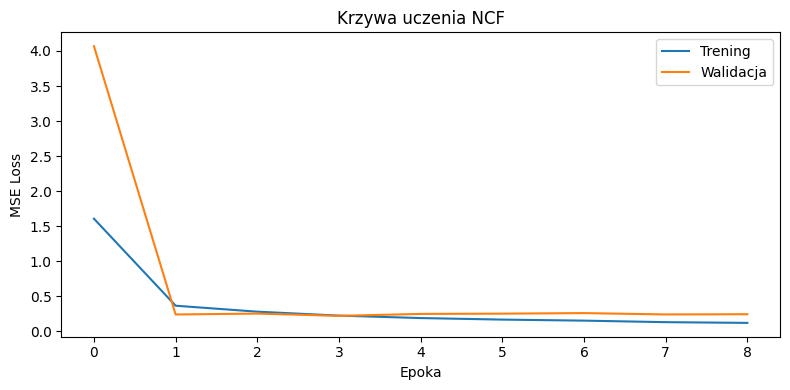

In [24]:
# Trening NCF
model_ncf = NCF(num_users, num_wines, emb_dim=50).to(device)
optimizer = optim.Adam(model_ncf.parameters(), lr=0.003, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
criterion = nn.MSELoss()

best_val_loss  = float("inf")
patience_count = 0
PATIENCE       = 5

train_losses, val_losses = [], []

print("Trening NCF (max 20 epok)...")
for epoch in range(20):
    # === Faza treningu ===
    model_ncf.train()
    total_train = 0
    for users, wines, ratings in train_loader:
        users, wines, ratings = users.to(device), wines.to(device), ratings.to(device)
        optimizer.zero_grad()
        preds = model_ncf(users, wines).squeeze()
        loss  = criterion(preds, ratings)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ncf.parameters(), 1.0)
        optimizer.step()
        total_train += loss.item()
    avg_train = total_train / len(train_loader)

    # === Faza walidacji ===
    model_ncf.eval()
    total_val = 0
    with torch.no_grad():
        for users, wines, ratings in test_loader:
            users, wines, ratings = users.to(device), wines.to(device), ratings.to(device)
            preds = model_ncf(users, wines).squeeze()
            total_val += criterion(preds, ratings).item()
    avg_val = total_val / len(test_loader)

    scheduler.step(avg_val)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"  Epoka {epoch+1:2d}: train={avg_train:.4f}  val={avg_val:.4f}", end="")

    # Zapisujemy najlepszy model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_count = 0
        torch.save(model_ncf.state_dict(), "best_ncf.pt")
        print(" ← najlepszy!", end="")
    else:
        patience_count += 1

    print()

    # Early stopping: jeśli przez PATIENCE epok brak poprawy, kończymy
    if patience_count >= PATIENCE:
        print(f"  Early stopping po epoce {epoch+1}")
        break

# Wczytujemy najlepszy model
model_ncf.load_state_dict(torch.load("best_ncf.pt"))
print(f"\nNajlepszy val loss: {best_val_loss:.4f}")

# Wykres krzywej uczenia
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Trening")
plt.plot(val_losses,   label="Walidacja")
plt.xlabel("Epoka")
plt.ylabel("MSE Loss")
plt.title("Krzywa uczenia NCF")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
# Ewaluacja NCF
model_ncf.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for users, wines, ratings in test_loader:
        preds = model_ncf(users.to(device), wines.to(device)).squeeze().cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(ratings.numpy())

preds_ncf = np.array(all_preds)
trues_ncf = np.array(all_true)

# Dodajemy predykcje do test_df żeby liczyć metryki per-user
test_df["pred_ncf"] = preds_ncf

metrics_ncf = {
    "Model": "NCF",
    "RMSE":  round(rmse(trues_ncf, preds_ncf), 4),
    "MAE":   round(mae(trues_ncf, preds_ncf),  4),
    "R2":    round(r2(trues_ncf, preds_ncf),   4),
    **ranking_per_user(test_df, "Rating", "pred_ncf", k=5),
    **ranking_per_user(test_df, "Rating", "pred_ncf", k=10),
}

print("Wyniki NCF:")
display(pd.DataFrame([metrics_ncf]))


Wyniki NCF:


,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
0,NCF,0.4703,0.3555,0.333,0.7649,0.8237,0.979,0.7455,0.9187,0.9832


## 7. XGBoost i Random Forest na surowych ID

Najprostsze podejście: podajemy modelowi tylko dwa numery
– `user_idx` i `wine_idx` – i każemy mu przewidzieć ocenę.

To trochę jakbyśmy uczyli model zapamiętywania numerów
zamiast rozumienia preferencji, ale zaskakująco dobrze działa.


In [26]:
X_train_raw = train_df[["user_idx", "wine_idx"]].values
y_train_raw = train_df["Rating"].values

X_test_raw  = test_df[["user_idx", "wine_idx"]].values
y_test_raw  = test_df["Rating"].values

# --- XGBoost ---
print("Trening XGBoost (raw)...")
model_xgb_raw = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method="hist",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbosity=0
)
model_xgb_raw.fit(X_train_raw, y_train_raw)
preds_xgb_raw = model_xgb_raw.predict(X_test_raw)
test_df["pred_xgb_raw"] = preds_xgb_raw

metrics_xgb_raw = {
    "Model": "XGBoost (raw)",
    "RMSE":  round(rmse(y_test_raw, preds_xgb_raw), 4),
    "MAE":   round(mae(y_test_raw, preds_xgb_raw),  4),
    "R2":    round(r2(y_test_raw, preds_xgb_raw),   4),
    **ranking_per_user(test_df, "Rating", "pred_xgb_raw", k=5),
    **ranking_per_user(test_df, "Rating", "pred_xgb_raw", k=10),
}

# --- Random Forest ---
print("Trening Random Forest (raw)...")
model_rf_raw = RandomForestRegressor(
    n_estimators=50, max_depth=10, n_jobs=-1, random_state=42
)
model_rf_raw.fit(X_train_raw, y_train_raw)
preds_rf_raw = model_rf_raw.predict(X_test_raw)
test_df["pred_rf_raw"] = preds_rf_raw

metrics_rf_raw = {
    "Model": "Random Forest (raw)",
    "RMSE":  round(rmse(y_test_raw, preds_rf_raw), 4),
    "MAE":   round(mae(y_test_raw, preds_rf_raw),  4),
    "R2":    round(r2(y_test_raw, preds_rf_raw),   4),
    **ranking_per_user(test_df, "Rating", "pred_rf_raw", k=5),
    **ranking_per_user(test_df, "Rating", "pred_rf_raw", k=10),
}

print("Wyniki XGBoost i RF (raw):")
display(pd.DataFrame([metrics_xgb_raw, metrics_rf_raw]))


Trening XGBoost (raw)...
Trening Random Forest (raw)...
Wyniki XGBoost i RF (raw):


,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
0,XGBoost (raw),0.5208,0.4009,0.1822,0.7452,0.8015,0.9720,0.7282,0.8996,0.9770
1,Random Forest (raw),0.5235,0.4059,0.1736,0.7428,0.7983,0.9715,0.7215,0.8902,0.9764


## 8. XGBoost i Random Forest na embeddingach NCF

Pomysł: wyciągamy nauczone embeddingi z NCF i podajemy je
do XGBoosta / RF jako cechy. To *hybryda* – NCF dostarcza
"rozumienia" preferencji, a XGB/RF uczy się na tym predykować.

**Analogia:** NCF to tłumacz, który konwertuje ID na opis
(„ten użytkownik lubi wytrawne, tego wina jest owocowe").
XGB dostaje już "przetłumaczone" dane.


In [27]:
def get_embeddings(model, loader, device):
    """Dla każdej pary (user, wine) zwraca konkatenację ich embeddingów."""
    model.eval()
    X_list, y_list = [], []
    with torch.no_grad():
        for users, wines, ratings in loader:
            u_emb = model.user_emb(users.to(device))
            w_emb = model.wine_emb(wines.to(device))
            # Łączymy dwa wektory w jeden → [user_emb | wine_emb]
            combined = torch.cat([u_emb, w_emb], dim=1).cpu().numpy()
            X_list.append(combined)
            y_list.append(ratings.numpy())
    return np.concatenate(X_list), np.concatenate(y_list)


print("Ekstrakcja embeddingów NCF...")
X_train_emb, y_train_emb = get_embeddings(model_ncf, train_loader, device)
X_test_emb,  y_test_emb  = get_embeddings(model_ncf, test_loader,  device)
print(f"Kształt X_train: {X_train_emb.shape}  (próbki × 100 cech)")


Ekstrakcja embeddingów NCF...
Kształt X_train: (120000, 100)  (próbki × 100 cech)


In [28]:
# --- XGBoost + embeddingi NCF ---
print("Trening XGBoost (embeddingi)...")
model_xgb_emb = xgb.XGBRegressor(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    tree_method="hist",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbosity=0
)
model_xgb_emb.fit(X_train_emb, y_train_emb)
preds_xgb_emb = model_xgb_emb.predict(X_test_emb)
test_df["pred_xgb_emb"] = preds_xgb_emb

metrics_xgb_emb = {
    "Model": "XGBoost (NCF emb)",
    "RMSE":  round(rmse(y_test_emb, preds_xgb_emb), 4),
    "MAE":   round(mae(y_test_emb, preds_xgb_emb),  4),
    "R2":    round(r2(y_test_emb, preds_xgb_emb),   4),
    **ranking_per_user(test_df, "Rating", "pred_xgb_emb", k=5),
    **ranking_per_user(test_df, "Rating", "pred_xgb_emb", k=10),
}

# --- Random Forest + embeddingi NCF ---
print("Trening Random Forest (embeddingi)...")
model_rf_emb = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_leaf=5,
    n_jobs=-1, random_state=42
)
model_rf_emb.fit(X_train_emb, y_train_emb)
preds_rf_emb = model_rf_emb.predict(X_test_emb)
test_df["pred_rf_emb"] = preds_rf_emb

metrics_rf_emb = {
    "Model": "Random Forest (NCF emb)",
    "RMSE":  round(rmse(y_test_emb, preds_rf_emb), 4),
    "MAE":   round(mae(y_test_emb, preds_rf_emb),  4),
    "R2":    round(r2(y_test_emb, preds_rf_emb),   4),
    **ranking_per_user(test_df, "Rating", "pred_rf_emb", k=5),
    **ranking_per_user(test_df, "Rating", "pred_rf_emb", k=10),
}

print("Wyniki hybryd:")
display(pd.DataFrame([metrics_xgb_emb, metrics_rf_emb]))


Trening XGBoost (embeddingi)...
Trening Random Forest (embeddingi)...
Wyniki hybryd:


,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
0,XGBoost (NCF emb),0.4648,0.3509,0.3487,0.7694,0.8278,0.9804,0.7466,0.9192,0.9841
1,Random Forest (NCF emb),0.4620,0.3486,0.3565,0.7681,0.8270,0.9803,0.7435,0.9166,0.9840


## 9. Zestawienie wszystkich modeli

In [29]:
all_results = [
    metrics_xgb_raw,
    metrics_rf_raw,
    metrics_ncf,
    metrics_xgb_emb,
    metrics_rf_emb,
    metrics_rp3,
]

COLS = [
    "Model",
    "RMSE", "MAE", "R2",
    "Precision@5", "Recall@5", "NDCG@5",
    "Precision@10", "Recall@10", "NDCG@10",
]

results_df = pd.DataFrame(all_results, columns=COLS)

print("=" * 70)
print("Zestawienie modeli (posortowane wg NDCG@10)")
print("=" * 70)
display(results_df.sort_values("NDCG@10", ascending=False, na_position="last"))


Zestawienie modeli (posortowane wg NDCG@10)


,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
3,XGBoost (NCF emb),0.4648,0.3509,0.3487,0.7694,0.8278,0.9804,0.7466,0.9192,0.9841
4,Random Forest (NCF emb),0.4620,0.3486,0.3565,0.7681,0.8270,0.9803,0.7435,0.9166,0.9840
2,NCF,0.4703,0.3555,0.3330,0.7649,0.8237,0.9790,0.7455,0.9187,0.9832
0,XGBoost (raw),0.5208,0.4009,0.1822,0.7452,0.8015,0.9720,0.7282,0.8996,0.9770
1,Random Forest (raw),0.5235,0.4059,0.1736,0.7428,0.7983,0.9715,0.7215,0.8902,0.9764
5,RP3β,NaN,NaN,NaN,0.7134,0.7693,0.9547,0.7008,0.8697,0.9571


## 10. Wykres: RMSE vs NDCG@10

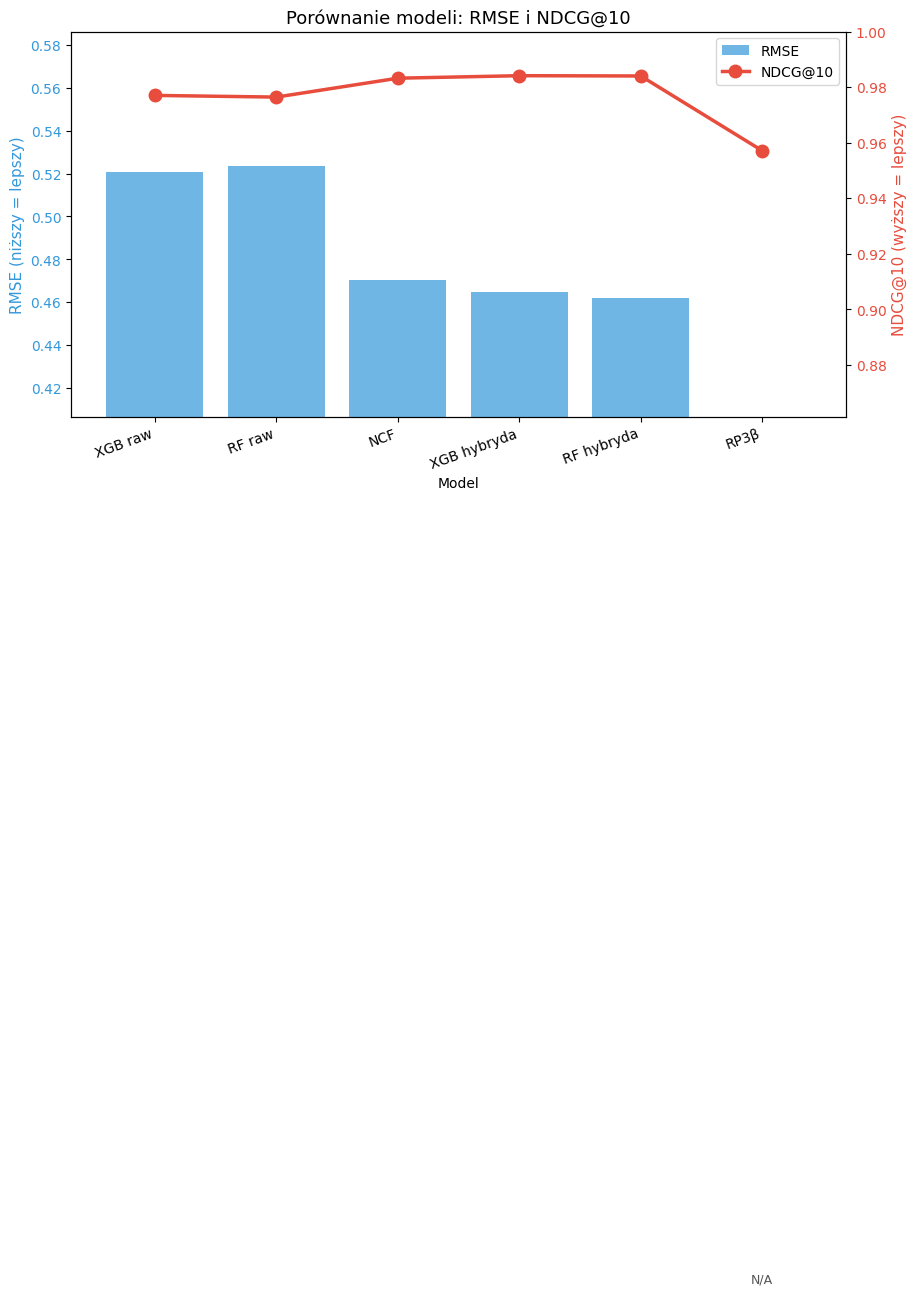

In [30]:
plot_df = results_df.copy()

# Skrócone nazwy dla osi X
short_names = {
    "XGBoost (raw)":          "XGB raw",
    "Random Forest (raw)":    "RF raw",
    "NCF":                    "NCF",
    "XGBoost (NCF emb)":      "XGB hybryda",
    "Random Forest (NCF emb)":"RF hybryda",
    "RP3β":                   "RP3β",
}
plot_df["Label"] = plot_df["Model"].map(short_names).fillna(plot_df["Model"])

fig, ax1 = plt.subplots(figsize=(10, 5))

# Słupki: RMSE (NaN dla RP3β → 0, z adnotacją)
rmse_vals = plot_df["RMSE"].fillna(0).values
bars = ax1.bar(plot_df["Label"], rmse_vals, color="#3498db", alpha=0.7, label="RMSE")
ax1.set_ylabel("RMSE (niższy = lepszy)", color="#3498db", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#3498db")

# Ustaw oś Y tylko dla modeli z RMSE
valid = plot_df["RMSE"].dropna()
if not valid.empty:
    ax1.set_ylim(valid.min() * 0.88, valid.max() * 1.12)

# Linia: NDCG@10
ax2 = ax1.twinx()
ax2.plot(plot_df["Label"], plot_df["NDCG@10"],
         color="#e74c3c", marker="o", linewidth=2.5,
         markersize=9, label="NDCG@10")
ax2.set_ylabel("NDCG@10 (wyższy = lepszy)", color="#e74c3c", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#e74c3c")
valid_ndcg = plot_df["NDCG@10"].dropna()
if not valid_ndcg.empty:
    ax2.set_ylim(valid_ndcg.min() * 0.9, 1.0)

# Adnotacje na słupkach
for bar, row in zip(bars, plot_df.itertuples()):
    label = "N/A" if pd.isna(row.RMSE) else ""
    if label:
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.002,
                 label, ha="center", fontsize=9, color="#555")

plt.title("Porównanie modeli: RMSE i NDCG@10", fontsize=13)
ax1.set_xlabel("Model")
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()


## 11. Przykład: rekomendacje dla użytkownika

Sprawdzamy co model hybryda (XGBoost + NCF embeddingi) poleca
konkretnemu użytkownikowi.


In [31]:
import random

def recommend_for_user(user_id, ncf_model, xgb_model,
                       user2idx, wine2idx, df_all,
                       top_n=5, n_candidates=500):
    """
    Generuje top-N rekomendacji dla jednego użytkownika.
    Kandydaci: losowe wina, których user jeszcze nie oceniał.
    """
    # Historia użytkownika
    history = (df_all[df_all["UserID"] == user_id]
               .sort_values("Rating", ascending=False)
               .head(5)[["WineID", "Rating"]])

    # Wina, których user jeszcze nie widział
    seen      = set(df_all[df_all["UserID"] == user_id]["WineID"])
    unseen    = [w for w in wine2idx if w not in seen]
    if len(unseen) > n_candidates:
        unseen = random.sample(unseen, n_candidates)

    # Tworzymy embeddingi NCF dla tych kandydatów
    u_idx = user2idx[user_id]
    w_idxs = [wine2idx[w] for w in unseen]

    ncf_model.eval()
    with torch.no_grad():
        u_t = torch.full((len(w_idxs),), u_idx, dtype=torch.long, device=device)
        w_t = torch.tensor(w_idxs, dtype=torch.long, device=device)
        feats = torch.cat([ncf_model.user_emb(u_t),
                           ncf_model.wine_emb(w_t)], dim=1).cpu().numpy()

    # Predykcja oceny przez XGBoost
    scores = xgb_model.predict(feats)

    recs = (pd.DataFrame({"WineID": unseen, "Predicted Rating": scores})
            .sort_values("Predicted Rating", ascending=False)
            .head(top_n))

    return history, recs


# Wybieramy przykładowego użytkownika z danych treningowych
example_user = train_df["UserID"].iloc[50]

history, recs = recommend_for_user(
    example_user, model_ncf, model_xgb_emb,
    user2idx, wine2idx, df
)

print(f"Użytkownik: {example_user}")
print("\nOstatnie wysokie oceny (historia):")
display(history)
print("\nRekomendowane wina:")
display(recs)


Użytkownik: 1197665

Ostatnie wysokie oceny (historia):


,WineID,Rating
4071,135871,4.5
131233,113050,4.5
44348,179084,4.0
50,136522,4.0
57215,179044,4.0



Rekomendowane wina:


,WineID,Predicted Rating
36,112084,4.775581
79,111417,4.739017
294,180330,4.674563
438,174184,4.641988
94,111395,4.572841


In [32]:
def serendipity_recommendations(user_id, ncf_model, xgb_model, df_all,
                                 user2idx, wine2idx, device,
                                 top_n=5, n_candidates=1000,
                                 surprise_factor=0.3):
    _, candidates_df = recommend_for_user(
        user_id, ncf_model, xgb_model,
        user2idx, wine2idx, df_all,
        top_n=n_candidates
    )

    wine_counts = df_all["WineID"].value_counts()
    log_max     = np.log1p(wine_counts.max())

    # Log-normalizacja — sensowna przy skośnym rozkładzie
    candidates_df["Popularity"] = (
        candidates_df["WineID"]
        .map(wine_counts).fillna(0)
        .apply(lambda c: np.log1p(c) / log_max)
    )
    candidates_df["Novelty"] = 1.0 - candidates_df["Popularity"]

    # Stała skala 1-5, nie lokalna min-max
    candidates_df["Rating_Norm"] = (
        candidates_df["Predicted Rating"].clip(1, 5) - 1
    ) / 4

    candidates_df["Serendipity"] = (
        (1 - surprise_factor) * candidates_df["Rating_Norm"] +
        surprise_factor       * candidates_df["Novelty"]
    )

    return (candidates_df
            .sort_values("Serendipity", ascending=False)
            .head(top_n)
            [["WineID", "Predicted Rating", "Popularity", "Novelty", "Serendipity"]])

In [33]:
example_user = train_df["UserID"].iloc[50]

print("=== Historia użytkownika (top-10 ocen) ===")
historia = (df[df["UserID"] == example_user]
            .sort_values("Rating", ascending=False)
            .head(10)[["WineID", "Rating"]])
display(historia)

print("\n=== Rekomendacje bez serendipity (surprise=0.0) ===")
display(serendipity_recommendations(
    example_user, model_ncf, model_xgb_emb, df,
    user2idx, wine2idx, device, surprise_factor=0.0
))

print("\n=== Rekomendacje z serendipity (surprise=0.4) ===")
display(serendipity_recommendations(
    example_user, model_ncf, model_xgb_emb, df,
    user2idx, wine2idx, device, surprise_factor=0.4
))

=== Historia użytkownika (top-10 ocen) ===


,WineID,Rating
4071,135871,4.5
131233,113050,4.5
44348,179084,4.0
50,136522,4.0
57215,179044,4.0
66126,106688,4.0
124209,112185,4.0
96648,171001,4.0
48773,155618,4.0
33052,101660,4.0



=== Rekomendacje bez serendipity (surprise=0.0) ===


,WineID,Predicted Rating,Popularity,Novelty,Serendipity
499,179131,4.707184,0.864027,0.135973,0.926796
133,180330,4.674563,0.617505,0.382495,0.918641
328,174184,4.641988,0.882189,0.117811,0.910497
470,140819,4.551866,0.560050,0.439950,0.887966
388,112664,4.497046,0.685328,0.314672,0.874262



=== Rekomendacje z serendipity (surprise=0.4) ===


,WineID,Predicted Rating,Popularity,Novelty,Serendipity
161,186159,4.293810,0.244103,0.755897,0.796430
192,108976,4.410597,0.299342,0.700658,0.791853
53,141193,4.249033,0.265104,0.734896,0.781314
284,199408,3.892273,0.188864,0.811136,0.758296
487,181203,3.635581,0.094432,0.905568,0.757564


In [34]:
wines_df.loc[wines_df["WineID"] == 184540]

,WineID,WineName,Type,Elaborate,Grapes,Harmonize,ABV,Body,Acidity,Code,Country,RegionID,RegionName,WineryID,WineryName,Website,Vintages
849,184540,Cabernet Sauvignon,Red,Varietal/100%,['Cabernet Sauvignon'],"['Beef', 'Lamb', 'Game Meat', 'Maturated Chees...",12.0,Very full-bodied,Medium,US,United States,1848,Napa Valley,57214,Shibumi Knoll Vineyards,http://www.shibumiknoll.com,"[2019, 2018, 2017, 2016, 2015, 2014, 2013, 201..."


In [35]:
def evaluate_serendipity_offline(model_ncf, model_xgb, df_all,
                                  user2idx, wine2idx, device,
                                  surprise_factor=0.4,
                                  n_users=100, top_n=10):
    """
    Dla każdego użytkownika:
    - "ukrywamy" jego wina testowe (udajemy, że ich nie oceniał)
    - sprawdzamy ile z nich trafia do top-N serendipity
    - sprawdzamy czy trafione mają wysoką ocenę (>= 4) i są niszowe
    """
    results = []

    # Weź użytkowników, którzy mają oceny w teście
    test_users = df_all[df_all["UserID"].isin(
        df_all["UserID"].value_counts()[lambda x: x >= top_n].index
    )]["UserID"].unique()[:n_users]

    for user_id in test_users:
        if user_id not in user2idx:
            continue

        # Wszystkie oceny tego usera
        user_ratings = df_all[df_all["UserID"] == user_id]

        # Dzielimy jego historię: 80% "widziane", 20% "testowe"
        n_test  = max(1, int(len(user_ratings) * 0.2))
        hidden  = user_ratings.tail(n_test)   # najnowsze = testowe
        visible = user_ratings.iloc[:-n_test] # starsze = "widziane"

        if len(visible) < 5:
            continue

        # Tymczasowo robimy df bez ukrytych ocen
        df_temp = df_all[~df_all.index.isin(hidden.index)]

        # Rekomendacje serendipity na okrojonym df
        try:
            recs = serendipity_recommendations(
                user_id, model_ncf, model_xgb_emb, df_temp,
                user2idx, wine2idx, device,
                top_n=top_n,
                n_candidates=1000,
                surprise_factor=surprise_factor
            )
        except Exception:
            continue

        # Sprawdzamy ile ukrytych win trafiło do rekomendacji
        hidden_wines    = set(hidden["WineID"])
        rec_wines       = set(recs["WineID"])
        hits            = hidden_wines & rec_wines

        # Wśród trafionych: ile miało ocenę >= 4?
        hit_ratings     = hidden[hidden["WineID"].isin(hits)]["Rating"]
        good_hits       = (hit_ratings >= 4).sum()

        # Średnia popularność rekomendacji (niska = bardziej niszowe)
        wine_counts     = df_all["WineID"].value_counts()
        avg_popularity  = recs["Popularity"].mean()

        results.append({
            "user_id":        user_id,
            "n_hidden":       n_test,
            "hits":           len(hits),
            "good_hits":      good_hits,       # trafione I dobrze ocenione
            "hit_rate":       len(hits) / top_n,
            "avg_popularity": avg_popularity,
        })

    return pd.DataFrame(results)

In [36]:
rows = []
for sf in [0.0, 0.2, 0.4, 0.6, 0.8]:
    df_eval = evaluate_serendipity_offline(
        model_ncf, model_xgb_emb, df,
        user2idx, wine2idx, device,
        surprise_factor=sf, n_users=200, top_n=10
    )
    rows.append({
        "surprise_factor":  sf,
        "avg_hit_rate":     round(df_eval["hit_rate"].mean(), 4),
        "avg_good_hits":    round(df_eval["good_hits"].mean(), 4),
        "avg_popularity":   round(df_eval["avg_popularity"].mean(), 4),
    })

display(pd.DataFrame(rows))

,surprise_factor,avg_hit_rate,avg_good_hits,avg_popularity
0,0.0,0.0095,0.095,0.6799
1,0.2,0.0000,0.000,0.3549
2,0.4,0.0000,0.000,0.2309
3,0.6,0.0000,0.000,0.1604
4,0.8,0.0000,0.000,0.1289


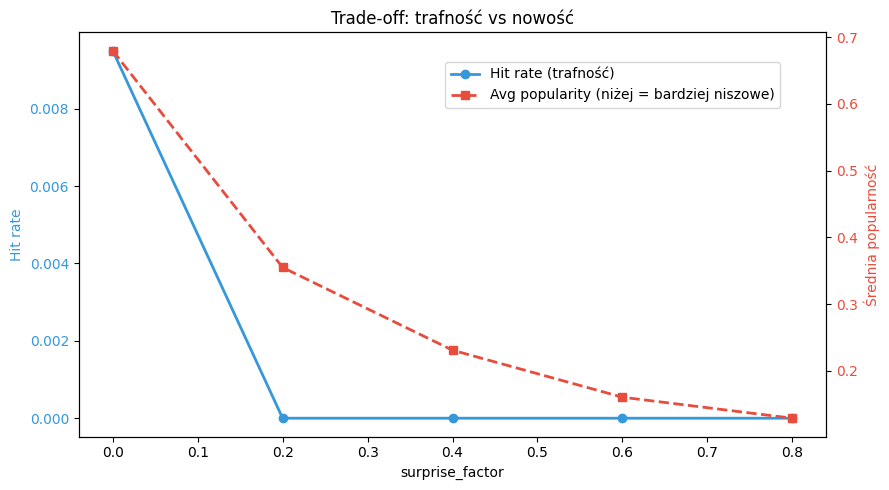

In [37]:
def serendipity_tradeoff_plot(rows_df):
    fig, ax1 = plt.subplots(figsize=(9, 5))

    ax1.plot(rows_df["surprise_factor"], rows_df["avg_hit_rate"],
             "o-", color="#3498db", linewidth=2, label="Hit rate (trafność)")
    ax1.set_ylabel("Hit rate", color="#3498db")
    ax1.tick_params(axis="y", labelcolor="#3498db")
    ax1.set_xlabel("surprise_factor")

    ax2 = ax1.twinx()
    ax2.plot(rows_df["surprise_factor"], rows_df["avg_popularity"],
             "s--", color="#e74c3c", linewidth=2, label="Avg popularity (niżej = bardziej niszowe)")
    ax2.set_ylabel("Średnia popularność", color="#e74c3c")
    ax2.tick_params(axis="y", labelcolor="#e74c3c")

    plt.title("Trade-off: trafność vs nowość")
    fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
    plt.tight_layout()
    plt.show()

serendipity_tradeoff_plot(pd.DataFrame(rows))

In [38]:
wine_counts = df["WineID"].value_counts()
print(wine_counts.describe())
print(f"\nMediana: {wine_counts.median()}")
print(f"Top 1% progu: {wine_counts.quantile(0.99):.0f} ocen")

# Ile win ma > 10 ocen?
print(f"Win z >10 ocenami: {(wine_counts > 10).sum()} / {len(wine_counts)}")

count    1007.000000
mean      148.957299
std       227.946427
min         1.000000
25%        16.000000
50%        53.000000
75%       164.000000
max      1540.000000
Name: count, dtype: float64

Mediana: 53.0
Top 1% progu: 951 ocen
Win z >10 ocenami: 840 / 1007


In [39]:
def serendipity_quality_check(df_all, surprise_factor_list,
                               model_ncf, model_xgb, user2idx, wine2idx, device,
                               n_users=50):
    # Średnia ocena wina w całym zbiorze = proxy jakości
    wine_avg_rating = df_all.groupby("WineID")["Rating"].mean()
    rows = []

    sample_users = df_all["UserID"].value_counts().head(n_users).index

    for sf in surprise_factor_list:
        avg_ratings, avg_pops = [], []

        for uid in sample_users:
            if uid not in user2idx:
                continue
            try:
                recs = serendipity_recommendations(
                    uid, model_ncf, model_xgb, df_all,
                    user2idx, wine2idx, device,
                    surprise_factor=sf, n_candidates=1000
                )
                avg_ratings.append(
                    recs["WineID"].map(wine_avg_rating).mean()
                )
                avg_pops.append(recs["Popularity"].mean())
            except Exception:
                continue

        rows.append({
            "surprise_factor":      sf,
            "avg_popularity":       round(np.mean(avg_pops),    3),
            "avg_wine_rating_glob": round(np.mean(avg_ratings), 3),
        })

    return pd.DataFrame(rows)

quality = serendipity_quality_check(
    df, [0.0, 0.2, 0.4, 0.6, 0.8],
    model_ncf, model_xgb_emb, user2idx, wine2idx, device
)
display(quality)

,surprise_factor,avg_popularity,avg_wine_rating_glob
0,0.0,0.714,4.651
1,0.2,0.299,4.612
2,0.4,0.210,4.417
3,0.6,0.148,4.242
4,0.8,0.112,4.001


In [40]:
wines_atrib_df = wines_df.drop(columns=["Website", "Vintages"])

In [65]:
# --- 1. PRZYGOTOWANIE DANYCH DO ANALIZY JAKOŚCIOWEJ ---
def get_wine_details(wine_ids, wines_df):
    # Kolumny, które najlepiej tłumaczą profil wina w pracy mgr/lic
    cols = ['WineID', 'WineName', 'Type', 'Grapes', 'Country', 'Body', 'Acidity', 'ABV']
    return wines_df.loc[wines_df["WineID"].isin(wine_ids), cols]

# Przykład dla Twojego użytkownika
example_user = train_df["UserID"].iloc[30]

# Pobieramy rekomendacje standardowe (SF=0) i niszowe (SF=0.4)
recs_std = serendipity_recommendations(example_user, model_ncf, model_xgb_emb, df, 
                                       user2idx, wine2idx, device, surprise_factor=0.0, top_n=10)

recs_sur_1 = serendipity_recommendations(example_user, model_ncf, model_xgb_emb, df, 
                                       user2idx, wine2idx, device, surprise_factor=0.4, top_n=10)

recs_sur_2 = serendipity_recommendations(example_user, model_ncf, model_xgb_emb, df, 
                                       user2idx, wine2idx, device, surprise_factor=0.8, top_n=10)

# Pobieramy historię (ulubione wina użytkownika)
user_history_ids = df[df["UserID"] == example_user].sort_values("Rating", ascending=False).head(10)["WineID"]

# Wyświetlanie tabel
print(f"\n{'='*20} ANALIZA JAKOŚCIOWA DLA UŻYTKOWNIKA {example_user} {'='*20}")
print("\nHISTORIA (Wina ocenione najwyżej):")
display(get_wine_details(user_history_ids, wines_df))

print("\nREKOMENDACJE STANDARDOWE (XGB Hybryda - wysoka precyzja, niska nowość):")
display(get_wine_details(recs_std["WineID"], wines_df))

print("\nREKOMENDACJE Z SERENDIPITY (Odkrywanie niszowych win):")
display(get_wine_details(recs_sur_1["WineID"], wines_df))


print("\nREKOMENDACJE Z SERENDIPITY (Odkrywanie niszowych win):")
display(get_wine_details(recs_sur_2["WineID"], wines_df))


# --- 2. GENEROWANIE WYKRESU TRADE-OFF (PRECYZJA VS NOWOŚĆ) ---
# Uruchamiamy pętlę dla różnych wartości surprise_factor
# sf_results = []
# for sf in [0.0, 0.2, 0.4, 0.6, 0.8]:
#     eval_df = evaluate_serendipity_offline(model_ncf, model_xgb_emb, df, 
#                                            user2idx, wine2idx, device, 
#                                            surprise_factor=sf, n_users=50, top_n=10)
#     sf_results.append({
#         'Surprise Factor': sf,
#         'Avg Popularity': eval_df['avg_popularity'].mean(),
#         'Hit Rate (Precision)': eval_df['hit_rate'].mean()
#     })

# sf_plot_df = pd.DataFrame(sf_results)

# fig, ax1 = plt.subplots(figsize=(10, 6))

# # Linia Popularności
# ax1.plot(sf_plot_df['Surprise Factor'], sf_plot_df['Avg Popularity'], 'g-o', label='Średnia Popularność')
# ax1.set_xlabel('Parametr Surprise (Serendipity)')
# ax1.set_ylabel('Popularność rekomendacji (niższa = bardziej niszowe)', color='g')

# # Linia Precyzji (Hit Rate)
# ax2 = ax1.twinx()
# ax2.plot(sf_plot_df['Surprise Factor'], sf_plot_df['Hit Rate (Precision)'], 'r-s', label='Hit Rate (Offline)')
# ax2.set_ylabel('Hit Rate (trafność w ukrytym teście)', color='r')

# plt.title('Dylemat rekomendacji: Trafność vs Nowość (Serendipity)')
# plt.grid(True, alpha=0.3)
# plt.show()


==================== ANALIZA JAKOŚCIOWA DLA UŻYTKOWNIKA 1204564 ====================

HISTORIA (Wina ocenione najwyżej):


,WineID,WineName,Type,Grapes,Country,Body,Acidity,ABV
69,101677,Reserva (Field Blend),Red,"['Sousão', 'Touriga Nacional', 'Touriga Franca...",Portugal,Very full-bodied,High,14.5
197,111434,Saint-Julien (Grand Cru Classé),Red,['Petit Verdot'],France,Full-bodied,High,13.0
234,111729,Saint-Estèphe,Red,['Petit Verdot'],France,Full-bodied,High,13.0
253,111987,Margaux du Château Margaux,Red,['Cabernet Sauvignon'],France,Full-bodied,High,14.0
377,135871,Barolo Marcenasco,Red,['Nebbiolo'],Italy,Very full-bodied,High,14.0
400,137224,Brunello di Montalcino,Red,['Sangiovese'],Italy,Very full-bodied,High,14.2
517,155334,Camins del Priorat,Red,['Garnacha'],Spain,Full-bodied,High,14.5
560,162502,Montes Alpha Cabernet Sauvignon,Red,['Cabernet Sauvignon'],Chile,Full-bodied,High,14.0
563,162507,Coyam,Red,"['Syrah/Shiraz', 'Petit Verdot', 'Carmenère', ...",Chile,Full-bodied,High,14.0
637,167419,Malbec,Red,['Malbec'],Argentina,Very full-bodied,High,13.5



REKOMENDACJE STANDARDOWE (XGB Hybryda - wysoka precyzja, niska nowość):


,WineID,WineName,Type,Grapes,Country,Body,Acidity,ABV
187,111395,Pauillac (Premier Grand Cru Classé),Red,"['Cabernet Sauvignon', 'Cabernet Franc', 'Merl...",France,Full-bodied,High,13.0
208,111475,Saint-Émilion Grand Cru (Premier Grand Cru Cla...,Red,['Cabernet Franc'],France,Full-bodied,Medium,13.5
258,112084,Oenothèque Brut Champagne,Sparkling,"['Pinot Noir', 'Chardonnay']",France,Medium-bodied,High,12.5
285,112664,Meursault Blanc,White,['Chardonnay'],France,Full-bodied,Medium,12.9
466,143130,Costa Russi Grappa di Nebbiolo,Dessert,['Nebbiolo'],Italy,Very full-bodied,High,45.0
772,179043,Special Selection Cabernet Sauvignon,Red,['Cabernet Sauvignon'],United States,Very full-bodied,Medium,14.5
786,179131,Dominus (Christian Moueix),Red,['Cabernet Franc'],United States,Full-bodied,Medium,14.5
809,180330,IX Estate Red,Red,"['Cabernet Sauvignon', 'Cabernet Franc', 'Merl...",United States,Full-bodied,Medium,15.1
827,182169,Fortis Cabernet Sauvignon,Red,['Cabernet Sauvignon'],United States,Very full-bodied,Medium,14.6
837,183379,Tychson Hill Vineyard Cabernet Sauvignon,Red,['Cabernet Sauvignon'],United States,Very full-bodied,Medium,14.9



REKOMENDACJE Z SERENDIPITY (Odkrywanie niszowych win):


,WineID,WineName,Type,Grapes,Country,Body,Acidity,ABV
186,111328,Lorenzhöfer Riesling Beerenauslese,Dessert,['Riesling'],Germany,Light-bodied,High,10.0
445,141193,Brachetto d'Acqui,Sparkling,['Brachetto'],Italy,Medium-bodied,High,6.0
481,144337,Tre Soli Tre Grappa Invecchiata,Dessert,['Nebbiolo'],Italy,Full-bodied,High,43.0
506,151878,Grappa Riserva Botti da Sherry,Dessert,['Nebbiolo'],Italy,Very full-bodied,High,44.0
552,161471,Oloroso V.O.R.S,Dessert/Port,['Palomino'],Spain,Full-bodied,High,21.0
820,181203,Pinot Noir,Red,['Pinot Noir'],United States,Medium-bodied,High,14.5
827,182169,Fortis Cabernet Sauvignon,Red,['Cabernet Sauvignon'],United States,Very full-bodied,Medium,14.6
847,184497,Moscato,White,['Muscat/Moscato'],United States,Full-bodied,High,10.0
939,194479,Santorini,White,['Assyrtiko'],Greece,Medium-bodied,High,13.0
999,199204,Late Harvest Riesling,Dessert,['Riesling'],New Zealand,Light-bodied,High,11.8



REKOMENDACJE Z SERENDIPITY (Odkrywanie niszowych win):


,WineID,WineName,Type,Grapes,Country,Body,Acidity,ABV
369,131656,Bobal Tierra de Castilla,Red,['Bobal'],Spain,Full-bodied,High,13.5
410,138096,Domiziano Negroamaro del Salento,Red,['Negroamaro'],Italy,Full-bodied,High,12.5
505,151328,Fragolino,Sparkling,['Fragolino'],Italy,Light-bodied,High,8.0
514,155249,Garnacha Rosé,Rosé,['Garnacha'],Spain,Full-bodied,High,13.0
515,155266,Tempranillo-Garnacha Rosé,Rosé,"['Tempranillo', 'Garnacha']",Spain,Full-bodied,Medium,11.5
715,174121,White Muscadel Jerepigo,Dessert,['Muscadelle'],South Africa,Full-bodied,High,17.0
763,178378,Blackwood Park Botrytis Riesling,Dessert,['Riesling'],Australia,Light-bodied,High,10.5
820,181203,Pinot Noir,Red,['Pinot Noir'],United States,Medium-bodied,High,14.5
999,199204,Late Harvest Riesling,Dessert,['Riesling'],New Zealand,Light-bodied,High,11.8
1006,200139,Drama Queen Rosé,Rosé,['Syrah/Shiraz'],New Zealand,Full-bodied,Medium,13.0


In [64]:
display(wines_df["Acidity"].where(wines_df["Acidity"] == "High").count())
display(wines_df["Acidity"].where(wines_df["Acidity"] == "Medium").count())
display(wines_df["Acidity"].where(wines_df["Acidity"] == "Low").count())

np.int64(740)

np.int64(249)

np.int64(18)